# Early Epoch Comparison

**Question**: How many checkpoint epochs does GLARE/GLAREx actually need?

**Motivation**: Computing GLARE requires a forward+backward pass through all checkpoint epochs for every training sample. Luca's thesis notes this as a computational bottleneck and suggests that a subset of epochs might suffice.

**Approach**: The 8-epoch run already saved per-sample, per-epoch gradient norms (`grad_norms.pkl`). We re-aggregate using only the first N epochs (N=1..8) without any retraining or re-running gradient computation.

**AUROC** (Area Under the ROC Curve): measures how well the method *ranks* mislabeled samples above clean ones, across all possible thresholds. AUROC=1.0 = perfect separation, AUROC=0.5 = random. It summarises the full precision/recall tradeoff in a single number.

In [12]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
from sklearn.metrics import roc_auc_score
from glare import calculate_glare

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [13]:
GRAD_NORMS_PKL = Path("/home/student/lisa_ma/results/glare/19-08-26_21:11_ep-8_single-gpu/results/grad_norms_20260819_211102.pkl")
GT_XLSX        = Path("/home/student/lisa_ma/evaluation/gt_mislabels_complete.xlsx")
OUTPUT_DIR     = Path("/home/student/lisa_ma/results/early_epoch_comparison")
OUTPUT_DIR.mkdir(exist_ok=True)

## Load data

In [14]:
gn        = pd.read_pickle(GRAD_NORMS_PKL)
df_gt     = pd.read_excel(GT_XLSX, dtype=str)
positives = set(df_gt["sample_id"].astype(str))

total_epochs = int(gn["epoch"].max()) + 1
n_values     = list(range(1, total_epochs + 1))

print(f"Epochs available : {total_epochs}")
print(f"GT mislabels     : {len(positives)}")
print(f"Total samples    : {gn['id'].nunique()}")

Epochs available : 8
GT mislabels     : 94
Total samples    : 19266


## Compute GLARE/GLAREx scores for each N

In [ ]:
def compute_auroc(scores_df, positives, score_col):
    y_true   = scores_df["id"].isin(positives).astype(int).values
    scores   = scores_df[score_col].values
    inverted = scores.max() - scores
    return roc_auc_score(y_true, inverted) if len(set(y_true)) > 1 else float("nan")

def recall_at_budget(scores_df, positives, score_col, budget_fracs):
    """Recall at fixed inspection budgets (fraction of training data checked)."""
    df = scores_df.copy()
    df["is_mislabel"] = df["id"].isin(positives).astype(int)
    df_sorted   = df.sort_values(score_col, ascending=True).reset_index(drop=True)
    total       = len(df_sorted)
    total_mis   = df_sorted["is_mislabel"].sum()
    cum_tp      = df_sorted["is_mislabel"].cumsum().values
    result = {}
    for frac in budget_fracs:
        k = max(1, int(np.ceil(frac * total))) - 1
        result[frac] = cum_tp[min(k, total - 1)] / total_mis if total_mis > 0 else 0.0
    return result

def threshold_table(scores_df, positives, n_epochs):
    """Integer threshold table for GLARE scores (same format as thesis table)."""
    y_true = scores_df["id"].isin(positives).astype(int).values
    scores = scores_df["glare score"].values.astype(int)
    rows = []
    for k in range(n_epochs):
        flagged   = scores <= k
        tp = int((flagged & (y_true == 1)).sum())
        fp = int((flagged & (y_true == 0)).sum())
        fn = int((~flagged & (y_true == 1)).sum())
        tn = int((~flagged & (y_true == 0)).sum())
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0
        rows.append(dict(
            threshold=k, flagged=tp+fp,
            frac_pct=round((tp+fp)/len(y_true)*100, 2),
            recall_pct=round(recall*100, 1),
            precision_pct=round(precision*100, 1),
            f1_pct=round(f1*100, 1),
            TP=tp, FP=fp, FN=fn, TN=tn,
        ))
    return pd.DataFrame(rows)

# Shared color palette for N=1..8, consistent across plots 3/4/5.
# Extends Plot 2's budget palette (teal, green, orange, red, purple) with
# navy and blue at the low end and medium purple before dark purple.
_EPOCH_COLOR_LIST = ["#2C3E50", "#2980B9", "#1ABC9C", "#2ECC71",
                     "#F39C12", "#E74C3C", "#9B59B6", "#8E44AD"]
EPOCH_COLORS = {n: _EPOCH_COLOR_LIST[i] for i, n in enumerate(range(1, 9))}

In [16]:
BUDGETS = [0.005, 0.01, 0.02, 0.05, 0.10]  # 0.5%, 1%, 2%, 5%, 10%

results = []  # summary rows
all_scores   = {}  # n -> scores_df
all_tables   = {}  # n -> threshold_df

for n in n_values:
    subset    = gn[gn["epoch"] < n].copy()
    scores_df = calculate_glare(subset)
    all_scores[n]  = scores_df
    all_tables[n]  = threshold_table(scores_df, positives, n)

    auroc_g  = compute_auroc(scores_df, positives, "glare score")
    auroc_gx = compute_auroc(scores_df, positives, "glarex score")
    rb_g     = recall_at_budget(scores_df, positives, "glare score",  BUDGETS)
    rb_gx    = recall_at_budget(scores_df, positives, "glarex score", BUDGETS)

    row = {"N": n, "AUROC_GLARE": auroc_g, "AUROC_GLAREx": auroc_gx}
    for b in BUDGETS:
        row[f"Recall_GLARE_{int(b*100)}pct"]  = round(rb_g[b]  * 100, 1)
        row[f"Recall_GLAREx_{int(b*100)}pct"] = round(rb_gx[b] * 100, 1)
    results.append(row)
    print(f"N={n:2d}  GLARE={auroc_g:.4f}  GLAREx={auroc_gx:.4f}")

df_summary = pd.DataFrame(results)

DEBUG: n_classes=4, n_epoch=1


N= 1  GLARE=0.7085  GLAREx=0.9330
DEBUG: n_classes=4, n_epoch=2
N= 2  GLARE=0.8587  GLAREx=0.9593
DEBUG: n_classes=4, n_epoch=3
N= 3  GLARE=0.8818  GLAREx=0.9629
DEBUG: n_classes=4, n_epoch=4
N= 4  GLARE=0.8946  GLAREx=0.9684
DEBUG: n_classes=4, n_epoch=5
N= 5  GLARE=0.8949  GLAREx=0.9698
DEBUG: n_classes=4, n_epoch=6
N= 6  GLARE=0.9008  GLAREx=0.9705
DEBUG: n_classes=4, n_epoch=7
N= 7  GLARE=0.9015  GLAREx=0.9709
DEBUG: n_classes=4, n_epoch=8
N= 8  GLARE=0.9017  GLAREx=0.9711


## Plot 1: AUROC vs Number of Epochs Used

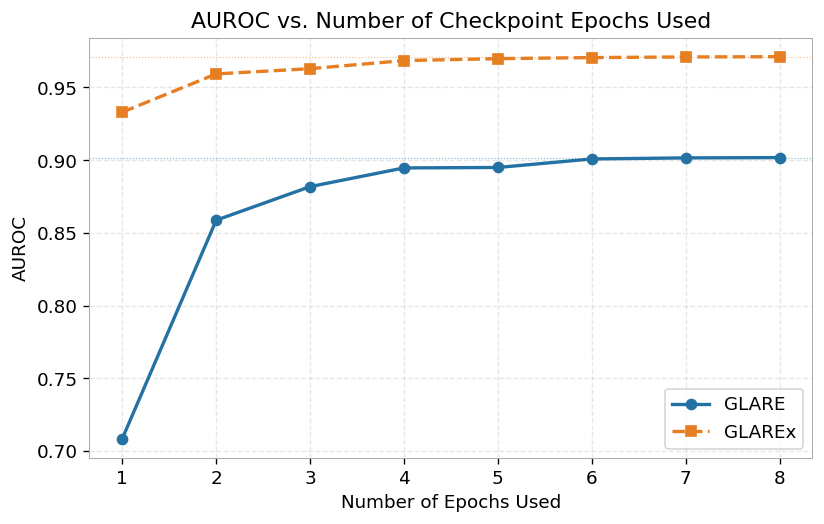

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(df_summary["N"], df_summary["AUROC_GLARE"],
        "o-", label="GLARE", color="#2471A3", linewidth=2, markersize=6)
ax.plot(df_summary["N"], df_summary["AUROC_GLAREx"],
        "s--", label="GLAREx", color="#E67E22", linewidth=2, markersize=6)

ax.axhline(df_summary["AUROC_GLARE"].iloc[-1],  color="#2471A3", linewidth=0.7, linestyle=":", alpha=0.5)
ax.axhline(df_summary["AUROC_GLAREx"].iloc[-1], color="#E67E22", linewidth=0.7, linestyle=":", alpha=0.5)

ax.set_xlabel("Number of Epochs Used")
ax.set_ylabel("AUROC")
ax.set_xticks(n_values)
ax.set_title("AUROC vs. Number of Checkpoint Epochs Used")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
for sp in ax.spines.values():
    sp.set_linewidth(0.6); sp.set_color("#AAAAAA")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "auroc_vs_epochs.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "auroc_vs_epochs.png", dpi=180, bbox_inches="tight")
plt.show()

## Plot 2: Recall at Fixed Budgets vs Number of Epochs

At a fixed inspection budget (e.g. check only 1% of training samples), how much recall do we lose by using fewer epochs?

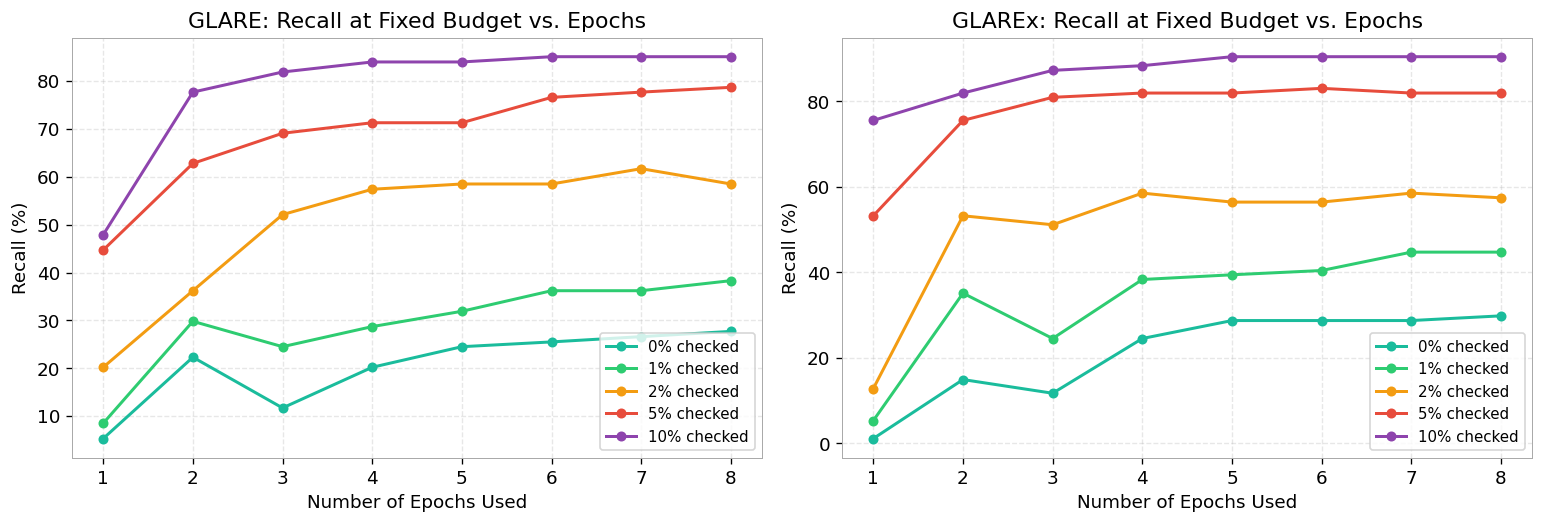

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
colors_budget = ["#1ABC9C", "#2ECC71", "#F39C12", "#E74C3C", "#8E44AD"]

for ax, method in zip(axes, ["GLARE", "GLAREx"]):
    for color, b in zip(colors_budget, BUDGETS):
        col = f"Recall_{method}_{int(b*100)}pct"
        ax.plot(df_summary["N"], df_summary[col],
                "o-", color=color, linewidth=1.8, markersize=5,
                label=f"{int(b*100)}% checked")
    ax.set_xlabel("Number of Epochs Used")
    ax.set_ylabel("Recall (%)")
    ax.set_xticks(n_values)
    ax.set_title(f"{method}: Recall at Fixed Budget vs. Epochs")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6); sp.set_color("#AAAAAA")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "recall_at_budget_vs_epochs.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "recall_at_budget_vs_epochs.png", dpi=180, bbox_inches="tight")
plt.show()

## Plot 3: Recall Curves (Recall vs Fraction Checked)

Full recall curves for N=1,2,4,8 to show where the curves diverge.

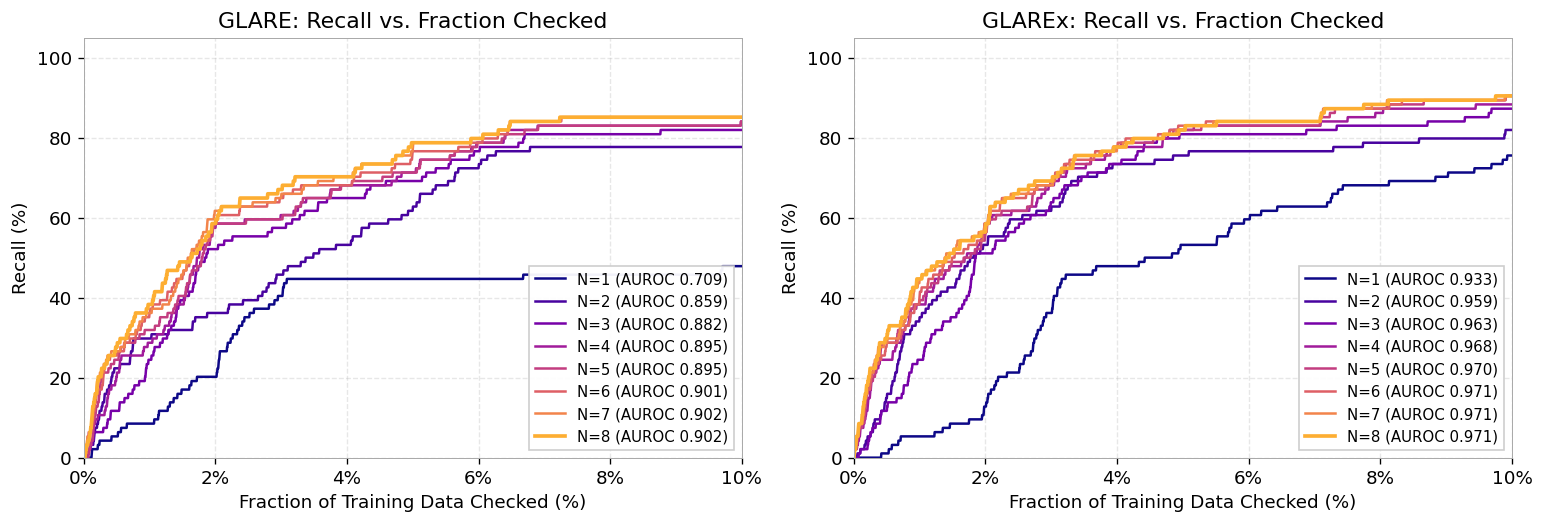

In [40]:
cmap      = plt.cm.plasma
color_map = {n: cmap(i / (len(n_values) - 1) * 0.82) for i, n in enumerate(n_values)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (method, score_col) in zip(axes, [("GLARE", "glare score"), ("GLAREx", "glarex score")]):
    for n in n_values:
        df_s     = all_scores[n].copy()
        df_s["is_mislabel"] = df_s["id"].isin(positives).astype(int)
        df_sorted = df_s.sort_values(score_col, ascending=True).reset_index(drop=True)
        total     = len(df_sorted)
        total_mis = df_sorted["is_mislabel"].sum()
        cum_tp    = df_sorted["is_mislabel"].cumsum().values / total_mis
        fracs     = np.arange(1, total + 1) / total

        auroc_col = "AUROC_GLARE" if method == "GLARE" else "AUROC_GLAREx"
        auroc_val = df_summary.loc[df_summary["N"] == n, auroc_col].values[0]
        lw = 2.2 if n == total_epochs else 1.5
        ax.plot(fracs * 100, cum_tp * 100,
                color=color_map[n], linewidth=lw,
                label=f"N={n} (AUROC {auroc_val:.3f})")

    ax.set_xlabel("Fraction of Training Data Checked (%)")
    ax.set_ylabel("Recall (%)")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_title(f"{method}: Recall vs. Fraction Checked")
    ax.legend(fontsize=9, loc="lower right", framealpha=0.95,
              edgecolor="#CCCCCC", fancybox=False)
    ax.grid(True, linestyle="--", alpha=0.3)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6); sp.set_color("#AAAAAA")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "recall_curves.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "recall_curves.png", dpi=180, bbox_inches="tight")
plt.show()

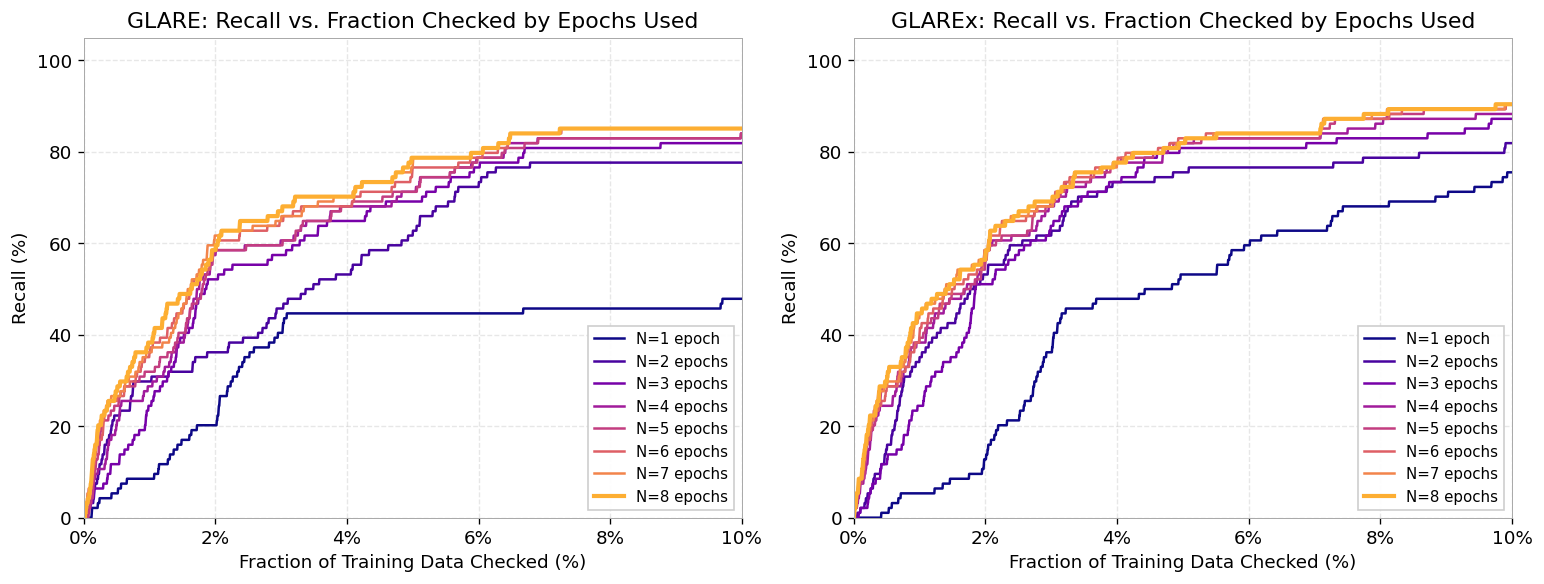

In [42]:
cmap2     = plt.cm.plasma
colors_n  = {n: cmap2(i / (len(n_values) - 1) * 0.82) for i, n in enumerate(n_values)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (method, score_col) in zip(axes, [("GLARE", "glare score"), ("GLAREx", "glarex score")]):
    for n in n_values:
        df_s = all_scores[n].copy()
        df_s["is_mislabel"] = df_s["id"].isin(positives).astype(int)
        df_sorted = df_s.sort_values(score_col, ascending=True).reset_index(drop=True)
        total     = len(df_sorted)
        total_mis = df_sorted["is_mislabel"].sum()
        cum_tp    = df_sorted["is_mislabel"].cumsum().values / total_mis
        fracs     = np.arange(1, total + 1) / total * 100

        lw = 2.5 if n == total_epochs else 1.5
        ax.plot(fracs, cum_tp * 100,
                color=colors_n[n], linewidth=lw,
                label=f"N={n} epoch{'s' if n > 1 else ''}")

    ax.set_xlabel("Fraction of Training Data Checked (%)")
    ax.set_ylabel("Recall (%)")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_title(f"{method}: Recall vs. Fraction Checked by Epochs Used")
    ax.legend(fontsize=9, loc="lower right", framealpha=0.95,
              edgecolor="#CCCCCC", fancybox=False)
    ax.grid(True, linestyle="--", alpha=0.3)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6); sp.set_color("#AAAAAA")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "recall_curves_by_n.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "recall_curves_by_n.png", dpi=180, bbox_inches="tight")
plt.show()


## Plot 4: Recall Curves per Method — lines coloured by N epochs

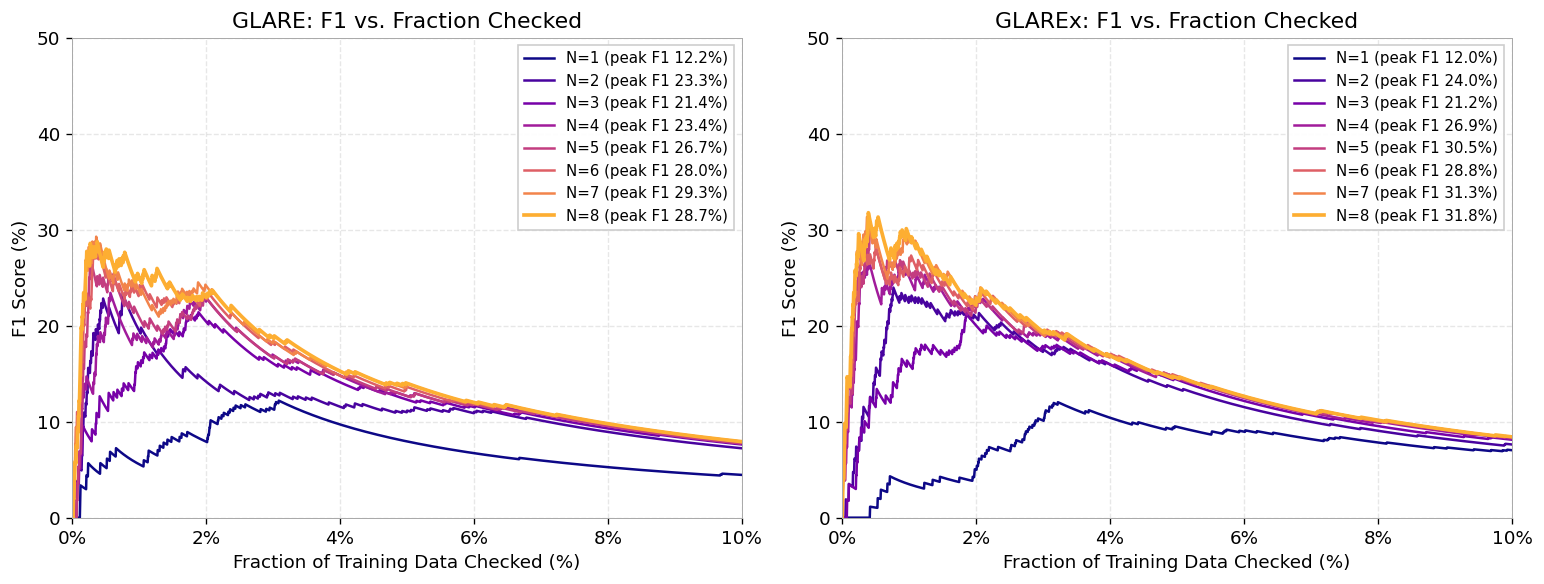


Peak F1 per N:

GLARE:
  N=1: peak F1 = 12.2%  at 3.09% checked
  N=2: peak F1 = 23.3%  at 0.76% checked
  N=3: peak F1 = 21.4%  at 1.89% checked
  N=4: peak F1 = 23.4%  at 0.58% checked
  N=5: peak F1 = 26.7%  at 0.29% checked
  N=6: peak F1 = 28.0%  at 0.36% checked
  N=7: peak F1 = 29.3%  at 0.36% checked
  N=8: peak F1 = 28.7%  at 0.38% checked

GLAREx:
  N=1: peak F1 = 12.0%  at 3.22% checked
  N=2: peak F1 = 24.0%  at 0.77% checked
  N=3: peak F1 = 21.2%  at 1.86% checked
  N=4: peak F1 = 26.9%  at 0.40% checked
  N=5: peak F1 = 30.5%  at 0.43% checked
  N=6: peak F1 = 28.8%  at 0.31% checked
  N=7: peak F1 = 31.3%  at 0.37% checked
  N=8: peak F1 = 31.8%  at 0.39% checked


In [41]:
cmap3      = plt.cm.plasma
color_map3 = {n: cmap3(i / (len(n_values) - 1) * 0.82) for i, n in enumerate(n_values)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (method, score_col) in zip(axes, [("GLARE", "glare score"), ("GLAREx", "glarex score")]):
    for n in n_values:
        df_s = all_scores[n].copy()
        df_s["is_mislabel"] = df_s["id"].isin(positives).astype(int)
        df_sorted  = df_s.sort_values(score_col, ascending=True).reset_index(drop=True)
        total      = len(df_sorted)
        total_mis  = df_sorted["is_mislabel"].sum()
        cum_tp     = df_sorted["is_mislabel"].cumsum().values
        inspected  = np.arange(1, total + 1)
        f1_curve   = np.where(inspected + total_mis > 0,
                              2 * cum_tp / (inspected + total_mis), 0.0)
        fracs      = inspected / total * 100

        lw = 2.2 if n == total_epochs else 1.5
        peak_f1 = f1_curve.max() * 100
        ax.plot(fracs, f1_curve * 100,
                color=color_map3[n], linewidth=lw,
                label=f"N={n} (peak F1 {peak_f1:.1f}%)")

    ax.set_xlabel("Fraction of Training Data Checked (%)")
    ax.set_ylabel("F1 Score (%)")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 50)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_title(f"{method}: F1 vs. Fraction Checked")
    ax.legend(fontsize=9, loc="upper right", framealpha=0.95,
              edgecolor="#CCCCCC", fancybox=False)
    ax.grid(True, linestyle="--", alpha=0.3)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6); sp.set_color("#AAAAAA")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "f1_curves.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "f1_curves.png", dpi=180, bbox_inches="tight")
plt.show()

# Peak F1 per N
print("\nPeak F1 per N:")
for method, score_col in [("GLARE", "glare score"), ("GLAREx", "glarex score")]:
    print(f"\n{method}:")
    for n in n_values:
        df_s = all_scores[n].copy()
        df_s["is_mislabel"] = df_s["id"].isin(positives).astype(int)
        df_sorted = df_s.sort_values(score_col, ascending=True).reset_index(drop=True)
        total_mis = df_sorted["is_mislabel"].sum()
        cum_tp    = df_sorted["is_mislabel"].cumsum().values
        inspected = np.arange(1, len(df_sorted) + 1)
        f1_curve  = 2 * cum_tp / (inspected + total_mis)
        print(f"  N={n}: peak F1 = {f1_curve.max()*100:.1f}%  at {inspected[f1_curve.argmax()]/len(df_sorted)*100:.2f}% checked")


## Plot 5: F1 Score Curves (F1 vs Fraction Checked)

F1 at each rank position: F1 = 2·TP / (inspected + total_mislabels). Shows the best operating point for each N.

## GLARE Threshold Table per N

Thesis-format threshold tables (same columns as the main evaluation) for each N.

In [20]:
from IPython.display import display

for n in n_values:
    print(f"\n--- N={n} epochs ---")
    display(all_tables[n][["threshold","flagged","frac_pct","recall_pct","precision_pct","f1_pct"]])


--- N=1 epochs ---


,threshold,flagged,frac_pct,recall_pct,precision_pct,f1_pct
0,0,612,3.18,44.7,6.9,11.9



--- N=2 epochs ---


,threshold,flagged,frac_pct,recall_pct,precision_pct,f1_pct
0,0,146,0.76,29.8,19.2,23.3
1,1,1269,6.59,76.6,5.7,10.6



--- N=3 epochs ---


...

,threshold,flagged,frac_pct,recall_pct,precision_pct,f1_pct
0,0,25,0.13,8.5,32.0,13.4
1,1,43,0.22,17.0,37.2,23.4
2,2,65,0.34,23.4,33.8,27.7
3,3,127,0.66,28.7,21.3,24.4
4,4,399,2.07,60.6,14.3,23.1
5,5,1364,7.08,84.0,5.8,10.8



--- N=7 epochs ---


,threshold,flagged,frac_pct,recall_pct,precision_pct,f1_pct
0,0,24,0.12,8.5,33.3,13.6
1,1,35,0.18,16.0,42.9,23.3
2,2,54,0.28,21.3,37.0,27.0
3,3,70,0.36,25.5,34.3,29.3
4,4,131,0.68,29.8,21.4,24.9
5,5,403,2.09,62.8,14.6,23.7
6,6,1365,7.09,84.0,5.8,10.8



--- N=8 epochs ---


,threshold,flagged,frac_pct,recall_pct,precision_pct,f1_pct
0,0,23,0.12,8.5,34.8,13.7
1,1,32,0.17,14.9,43.8,22.2
2,2,40,0.21,18.1,42.5,25.4
3,3,60,0.31,22.3,35.0,27.3
4,4,73,0.38,25.5,32.9,28.7
5,5,137,0.71,33.0,22.6,26.8
6,6,404,2.10,62.8,14.6,23.7
7,7,1365,7.09,84.0,5.8,10.8


## AUROC Summary Table

In [21]:
display(df_summary[["N", "AUROC_GLARE", "AUROC_GLAREx"] +
                   [f"Recall_GLARE_{int(b*100)}pct" for b in BUDGETS] +
                   [f"Recall_GLAREx_{int(b*100)}pct" for b in BUDGETS]])

,N,AUROC_GLARE,AUROC_GLAREx,Recall_GLARE_0pct,Recall_GLARE_1pct,Recall_GLARE_2pct,Recall_GLARE_5pct,Recall_GLARE_10pct,Recall_GLAREx_0pct,Recall_GLAREx_1pct,Recall_GLAREx_2pct,Recall_GLAREx_5pct,Recall_GLAREx_10pct
0,1,0.708539,0.932995,5.3,8.5,20.2,44.7,47.9,1.1,5.3,12.8,53.2,75.5
1,2,0.858703,0.959269,22.3,29.8,36.2,62.8,77.7,14.9,35.1,53.2,75.5,81.9
2,3,0.881774,0.962891,11.7,24.5,52.1,69.1,81.9,11.7,24.5,51.1,80.9,87.2
3,4,0.894644,0.968448,20.2,28.7,57.4,71.3,84.0,24.5,38.3,58.5,81.9,88.3
4,5,0.894942,0.969772,24.5,31.9,58.5,71.3,84.0,28.7,39.4,56.4,81.9,90.4
5,6,0.900805,0.970513,25.5,36.2,58.5,76.6,85.1,28.7,40.4,56.4,83.0,90.4
6,7,0.901537,0.970938,26.6,36.2,61.7,77.7,85.1,28.7,44.7,58.5,81.9,90.4
7,8,0.901742,0.971121,27.7,38.3,58.5,78.7,85.1,29.8,44.7,57.4,81.9,90.4


## Save Excel

In [22]:
ts       = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = OUTPUT_DIR / f"early_epoch_comparison_{ts}.xlsx"

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    df_summary.to_excel(writer, sheet_name="Summary_AUROC", index=False)
    for n in n_values:
        all_tables[n].to_excel(writer, sheet_name=f"GLARE_N{n}", index=False)

print(f"Saved: {out_path}")

Saved: /home/student/lisa_ma/results/early_epoch_comparison/early_epoch_comparison_20260923_144611.xlsx
